In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
num_rows = 1500

date_range = pd.date_range(start='2026-06-01', periods=num_rows, freq='h')
df = pd.DataFrame({
    'date': date_range.strftime('%Y-%m-%d'),
    'time': date_range.strftime('%H:%M:%S'),
    'Bin ID': np.random.choice(['BIN_001', 'BIN_002', 'BIN_003', 'BIN_004', 'BIN_005'], size=num_rows),
    'week no': np.random.randint(22, 26, size=num_rows),
    'total(liters)': np.random.choice([50, 100, 120], size=num_rows)
})

# I'm writing the hours for more precise calculations
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

# I'm assigning the real coordinates
# Commercial hubs get higher multipliers for waste accumulation
locations = {
    'BIN_001': ('Koramangala (Commercial)', 12.9352, 77.6245, 1.8),
    'BIN_002': ('Indiranagar (Commercial)', 12.9719, 77.6412, 1.9),
    'BIN_003': ('Jayanagar (Residential)', 12.9308, 77.5838, 1.1),
    'BIN_004': ('Whitefield (IT Park)', 12.9698, 77.7499, 1.6),
    'BIN_005': ('HSR Layout (Residential)', 12.9141, 77.6411, 1.2)
}

df['location'] = df['Bin ID'].map(lambda x: locations[x][0])
df['latitude'] = df['Bin ID'].map(lambda x: locations[x][1])
df['longitude'] = df['Bin ID'].map(lambda x: locations[x][2])
area_weight = df['Bin ID'].map(lambda x: locations[x][3])

#Environmental Sensor data
df['temperature (in ºC)'] = np.round(np.random.uniform(22.0, 34.0, size=num_rows), 1)
# Battery drains faster if the temperature environment is hot
df['battery level'] = np.round(100.0 - (df['temperature (in ºC)'] * 1.5) - np.random.uniform(0, 15, size=num_rows), 1)
df['battery level'] = df['battery level'].clip(5.0, 100.0)


# Peak hours (Lunch 12-2 pm, Dinner/Evening 5-8 pm) cause heavy fill rates
def calculate_fill_percentage(row, weight):
    hr = row['hour']
    base_fill = np.random.uniform(10, 45) # Baseline fill

    if 17 <= hr <= 21: # Evening rush hour peak
        base_fill += np.random.uniform(35, 50)
    elif 12 <= hr <= 14: # Lunch hour peak
        base_fill += np.random.uniform(20, 35)

    final_pct = base_fill * weight
    return min(round(final_pct, 2), 100.0)

df['fill percentage'] = df.apply(lambda r: calculate_fill_percentage(r, locations[r['Bin ID']][3]), axis=1)
df['fill level (in liters)'] = np.round((df['fill percentage'] / 100) * df['total(liters)'], 2)
df['bin level'] = np.round(100 - df['fill percentage'], 2)

# (1 = Full/Alert Needed, 0 = Safe)
df['filled status'] = (df['fill percentage'] >= 75).astype(int)

print("Realistic Smart-City Dataset Constructed!")
print(f"Total Bins Evaluated: {len(df)} | Total Full Bins Detected: {df['filled status'].sum()}")
print(df[['time', 'location', 'fill percentage', 'filled status']].head(5))

Realistic Smart-City Dataset Constructed!
Total Bins Evaluated: 1500 | Total Full Bins Detected: 428
       time                  location  fill percentage  filled status
0  00:00:00      Whitefield (IT Park)            70.07              0
1  01:00:00  HSR Layout (Residential)            26.35              0
2  02:00:00   Jayanagar (Residential)            24.03              0
3  03:00:00  HSR Layout (Residential)            12.30              0
4  04:00:00  HSR Layout (Residential)            40.57              0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# I'm getting the hour of the day from the time string
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

df_processed = pd.get_dummies(df, columns=['location'], drop_first=True)

# I chose inputs for my model

features = ['week no', 'latitude', 'longitude', 'temperature (in ºC)', 'battery level', 'hour']
features += [col for col in df_processed.columns if 'location_' in col]

X = df_processed[features]
y = df_processed['filled status']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# I'm scaling the features so columns like temperature and coordinates have
# equal weight
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete! Training set size:", X_train_scaled.shape[0])

Data preprocessing complete! Training set size: 1200



=================== Random Forest Classifier Scores ===================
Accuracy : 0.8667
Precision: 0.8382  (Low false alarms)
Recall   : 0.6628     (Caught all full bins)
F1-Score : 0.7403


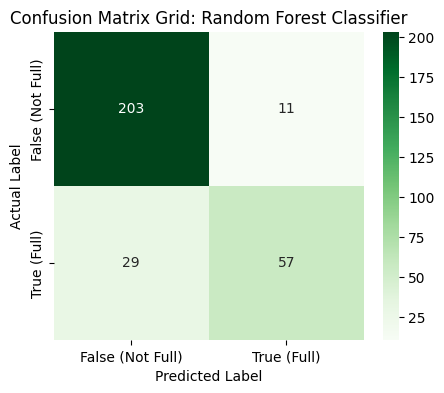


=================== XGBoost Classifier Scores ===================
Accuracy : 0.9000
Precision: 0.8684  (Low false alarms)
Recall   : 0.7674     (Caught all full bins)
F1-Score : 0.8148


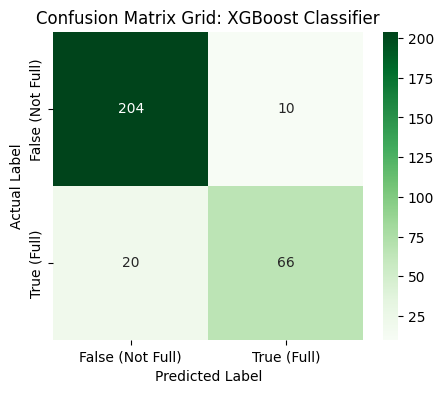

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize our two distinct classifiers
models = {
    "Random Forest Classifier": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost Classifier": XGBClassifier(random_state=42, eval_metric='logloss')
}


for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    # I'm computing the metrics mentioned
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=================== {name} Scores ===================")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}  (Low false alarms)")
    print(f"Recall   : {recall:.4f}     (Caught all full bins)")
    print(f"F1-Score : {f1:.4f}")
    print("========================================================")

    # Plot the required Confusion Matrix matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['False (Not Full)', 'True (Full)'],
                yticklabels=['False (Not Full)', 'True (Full)'])
    plt.title(f'Confusion Matrix Grid: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()